# Phase 2: Logistic Softmax Classification

This notebook presents a clean end-to-end pipeline for multi-class MNIST classification using softmax regression with HOG features.

**Main steps:**
1. Load the dataset and inspect images.
2. Prepare the data and extract HOG features.
3. Train softmax regression with regularization and early stopping.
4. Evaluate the model with accuracy, precision, recall, F1, and confusion matrix.

## 1) Environment Setup and Imports

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from tqdm import tqdm
from skimage.feature import hog

repo_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.insert(0, repo_root)

from src.utils.mnist_features import load_mnist, split_data, balance_multi_classes, normalize_data, build_features, class_distribution, extract_hog_features
from src.utils.evaluation import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, per_class_accuracy
from src.utils.bias_variance_analysis import learning_curve, complexity_curve, summarize_bias_variance
from src.utils.model_diagnostics import build_learning_curve, plot_learning_curve, print_diagnosis
from src.models.logistic_softmax import SoftmaxClassifier

In [2]:
# Explicit experiment config
RANDOM_STATE = 42
DATA_PATH = "../../data/mnist.npz"

TEST_SIZE = 0.20
VAL_SIZE = 0.0

# Optional class-imbalance handling (applied on train split only).
APPLY_CLASS_BALANCING = True
BALANCE_METHOD = "undersample"

FEATURES = ["hog"]
CV_FOLDS = 5

print("RANDOM_STATE:", RANDOM_STATE)
print("FEATURES:", FEATURES)
print("CV_FOLDS:", CV_FOLDS)
print("DATA_PATH:", DATA_PATH)
print("APPLY_CLASS_BALANCING:", APPLY_CLASS_BALANCING)
print("BALANCE_METHOD:", BALANCE_METHOD)

RANDOM_STATE: 42
FEATURES: ['hog']
CV_FOLDS: 5
DATA_PATH: ../../data/mnist.npz
APPLY_CLASS_BALANCING: True
BALANCE_METHOD: undersample


## 2) Load and Inspect MNIST Dataset

Full dataset shape: (70000, 28, 28), Labels shape: (70000,)
Class distribution: {0: 6903, 1: 7877, 2: 6990, 3: 7141, 4: 6824, 5: 6313, 6: 6876, 7: 7293, 8: 6825, 9: 6958}


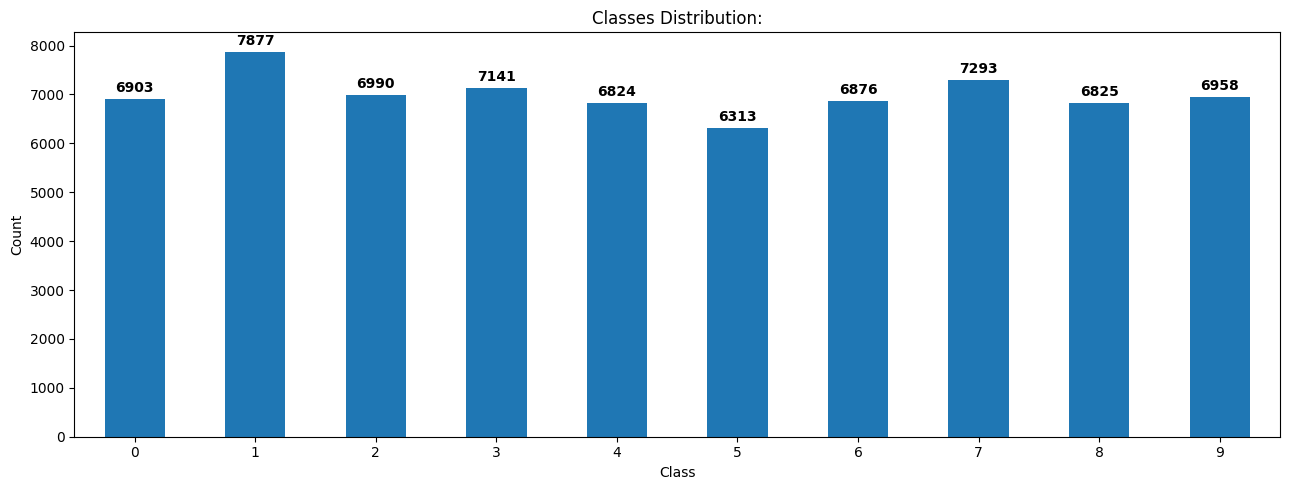

In [3]:
# Load the full MNIST dataset
x_all, y_all = load_mnist(DATA_PATH)
print(f'Full dataset shape: {x_all.shape}, Labels shape: {y_all.shape}')
print('Class distribution:', class_distribution(y_all))

label_counts = pd.Series(y_all).value_counts().reindex([0,1,2,3,4,5,6,7,8,9], fill_value=0)

plt.figure(figsize=(13, 5))
ax = label_counts.plot(kind='bar', rot=0)
for bar in ax.patches:
    height = bar.get_height()
    ax.text( bar.get_x() + bar.get_width() / 2, height + max(label_counts) * 0.01, f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold' )
plt.title(f'Classes Distribution:')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 3) Preprocessing 

1. Split the data 
2. Balance Training Set

In [4]:
# Split 80% train, 0% static val, 20% test
x_train, y_train, _, _, x_test, y_test = split_data(
    x_all, y_all, TEST_SIZE, VAL_SIZE, RANDOM_STATE
)
print(f'Train size: {len(y_train)} | Test size: {len(y_test)}')

# Balance the training data (Under-sampling)
print('\nBalancing multi-class training data...')
x_train, y_train = balance_multi_classes(x_train, y_train)
print(f'Balanced train size: {len(y_train)}')

# Create table with class distribution
counts_train = class_distribution(y_train)
counts_test = class_distribution(y_test)

table_df = pd.DataFrame({
    'Digit': list(range(10)),
    'Train Count': [counts_train.get(i, 0) for i in range(10)],
    'Test Count': [counts_test.get(i, 0) for i in range(10)],
})

# Show as a normal notebook table
display(table_df)

Train size: 56000 | Test size: 14000

Balancing multi-class training data...
Balanced train size: 50400


,Digit,Train Count,Test Count
0,0,5040,1343
1,1,5040,1600
2,2,5040,1380
3,3,5040,1433
4,4,5040,1295
5,5,5040,1273
6,6,5040,1396
7,7,5040,1503
8,8,5040,1357
9,9,5040,1420


## 4) Feature Extraction
**HOG**: Histogram of Oriented Gradients – captures edge/shape information


In [ ]:
def visualize_hog_dominant_directions(img, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2)):
    # 1. Compute HOG features
    features, hog_image = hog(
        img,
        orientations=orientations,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=cells_per_block,
        visualize=True
    )

    # 2. Dynamically calculate the shape for reshaping
    # n_cells = image_size // pixels_per_cell
    n_cells_h = img.shape[0] // pixels_per_cell[0]
    n_cells_w = img.shape[1] // pixels_per_cell[1]

    # n_blocks = n_cells - cells_per_block + 1
    n_blocks_h = n_cells_h - cells_per_block[0] + 1
    n_blocks_w = n_cells_w - cells_per_block[1] + 1

    # 3. Reshape the flat feature vector
    # Shape: (n_blocks_h, n_blocks_w, block_h, block_w, orientations)
    reshaped_features = features.reshape(
        (n_blocks_h, n_blocks_w, cells_per_block[0], cells_per_block[1], orientations)
    )

    # 4. Plotting
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    # Left: Original Image
    ax[0].imshow(img, cmap='gray')
    ax[0].set_title("Original Image")

    # Right: Dominant Directions Overlay
    ax[1].imshow(img, cmap='gray', alpha=0.5)  # Dim the background to see arrows clearly

    # Iterate through blocks and cells
    for i in range(n_blocks_h):
        for j in range(n_blocks_w):
            for r in range(cells_per_block[0]):
                for c in range(cells_per_block[1]):
                    bins = reshaped_features[i, j, r, c, :]
                    max_bin = np.argmax(bins)
                    magnitude = bins[max_bin]

                    # Calculate angle
                    angle_deg = max_bin * (180 / orientations)
                    angle_rad = np.deg2rad(angle_deg)

                    # Center of the cell: (Block Index + Cell Index) * Cell Size + Half Cell Size
                    ypos = (i + r) * pixels_per_cell[0] + (pixels_per_cell[0] // 2)
                    xpos = (j + c) * pixels_per_cell[1] + (pixels_per_cell[1] // 2)

                    if magnitude > 0.1:
                        ax[1].quiver(xpos, ypos, np.cos(angle_rad), -np.sin(angle_rad),
                                     color='red', scale=15, headwidth=3, pivot='middle')

    ax[1].set_title(f"Dominant HOG (Bins: {orientations})")
    plt.tight_layout()
    plt.show()

# Example Usage:
visualize_hog_dominant_directions(x_train[0], orientations=9, pixels_per_cell=(4, 4), cells_per_block=(2, 2))

In [6]:
x_train_hog = extract_hog_features(x_train, pixels_per_cell=(4, 4), cells_per_block=(2, 2), orientations=9)
x_test_hog  = extract_hog_features(x_test, pixels_per_cell=(4, 4), cells_per_block=(2, 2), orientations=9)

## 6) Softmax Training Function

In [9]:
# Train SoftmaxClassifier on raw images (HOG preprocessing is automatic)
clf = SoftmaxClassifier(
    num_classes=10,
    batch_size=32,
    learning_rate=0.1,
    lambda_reg=1e-5,
    max_epochs=200,
    val_fraction=0.1,
    validation_patience=15,
    epsilon=1e-4,
    seed=42,
    use_hog=True,
    hog_orientations=9,
    hog_pixels_per_cell=(4, 4),
    hog_cells_per_block=(2, 2),
    verbose=True
)

clf.fit(x_train, y_train)

Feature dimension: 1296  (train 45360, val 5040)
Epoch    0  val_loss=0.109613
Epoch    1  val_loss=0.102205
Epoch    2  val_loss=0.103321
Epoch    3  val_loss=0.107576
Epoch    4  val_loss=0.104666
Epoch    5  val_loss=0.105783
Epoch    6  val_loss=0.109321
Epoch    7  val_loss=0.110144
Epoch    8  val_loss=0.116624
Epoch    9  val_loss=0.111758
Epoch   10  val_loss=0.115938
Epoch   11  val_loss=0.113707
Epoch   12  val_loss=0.120973
Epoch   13  val_loss=0.119030
Epoch   14  val_loss=0.120823
Epoch   15  val_loss=0.119711
Epoch   16  val_loss=0.120127
Early stopping at epoch 17.


In [ ]:
# Evaluate on test set
metrics = clf.evaluate(x_test, y_test)

print(f"\n{'='*70}")
print("TEST SET EVALUATION")
print(f"{'='*70}")
print(f"Accuracy: {metrics['accuracy']:.4f}")
print(f"\nPer-class Precision:\n{metrics['precision']}")
print(f"\nPer-class Recall:\n{metrics['recall']}")
print(f"\nPer-class F1-score:\n{metrics['f1']}")

# Display confusion matrix
cm = metrics['confusion']
print(f"\nConfusion Matrix:\n{cm}")

## 7) Functions

In [ ]:
import itertools

def kfold_indices(N, K, seed=42):
    """
    Generate K pairs of (train_indices, val_indices) for K-fold CV.
    """
    rng = np.random.default_rng(seed)
    idx = rng.permutation(N)              # shuffle once

    fold_sizes = np.full(K, N // K)
    fold_sizes[:N % K] += 1              # distribute remainder evenly

    current = 0
    for size in fold_sizes:
        val_idx   = idx[current: current + size]
        train_idx = np.concatenate([idx[:current], idx[current + size:]])
        yield train_idx, val_idx
        current += size

def cross_validate(X, y, params, K=5, seed=42, verbose=False):
    """
    Run K-fold CV for a single hyperparameter combination using SoftmaxClassifier.
    """
    fold_accs = []

    for fold_idx, (tr_idx, val_idx) in enumerate(kfold_indices(X.shape[0], K, seed)):
        X_tr,  y_tr  = X[tr_idx],  y[tr_idx]
        X_val, y_val = X[val_idx], y[val_idx]

        # Create and train SoftmaxClassifier with given parameters
        clf = SoftmaxClassifier(
            num_classes=10,
            batch_size=params.get('batch_size', 64),
            learning_rate=params.get('learning_rate', 0.1),
            lambda_reg=params.get('lambda_reg', 1e-4),
            max_epochs=params.get('max_epochs', 100),
            val_fraction=0.1,
            validation_patience=params.get('validation_patience', 7),
            epsilon=1e-4,
            seed=seed + fold_idx,
            use_hog=True,
            verbose=False
        )
        
        clf.fit(X_tr, y_tr)
        
        metrics = clf.evaluate(X_val, y_val)
        acc = metrics['accuracy']
        fold_accs.append(acc)

        if verbose:
            print(f"  Fold {fold_idx+1}/{K}  acc={acc:.4f}")

    mean_acc = float(np.mean(fold_accs))
    std_acc  = float(np.std(fold_accs))

    if verbose:
        print(f"  → mean={mean_acc:.4f}  std={std_acc:.4f}")

    return mean_acc, std_acc, fold_accs

def grid_search(X, y, param_grid, K=5, seed=42, verbose=True):
    """
    Exhaustive grid search over all combinations in param_grid using SoftmaxClassifier.
    """
    # build all combinations
    keys   = list(param_grid.keys())
    values = list(param_grid.values())
    combos = list(itertools.product(*values))

    if verbose:
        print(f"Grid search: {len(combos)} combinations x {K} folds "
              f"= {len(combos)*K} training runs\n")

    results = []

    for i, combo in enumerate(combos):
        params = dict(zip(keys, combo))

        if verbose:
            print(f"[{i+1}/{len(combos)}] {params}")

        mean_acc, std_acc, fold_accs = cross_validate(
            X, y, params, K=K, seed=seed, verbose=verbose
        )

        results.append({
            'params'   : params,
            'mean_acc' : mean_acc,
            'std_acc'  : std_acc,
            'fold_accs': fold_accs,
        })

        if verbose:
            print()

    # sort best first
    results.sort(key=lambda r: r['mean_acc'], reverse=True)

    best_params = results[0]['params']

    if verbose:
        print("=" * 60)
        print(f"Best params  : {best_params}")
        print(f"Best CV acc  : {results[0]['mean_acc']:.4f} "
              f"± {results[0]['std_acc']:.4f}")

    return best_params, results

## 8) Cross-Validation & Hyperparameter Grid Search

In [ ]:
best_params, results = grid_search(
    X=x_train,
    y=y_train,
    param_grid={
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'lambda_reg': [1e-5, 1e-4, 1e-3],
        'batch_size': [32, 64, 128]
    },
    K=5,
    seed=42,
    verbose=True
)

print(f"\nBest hyperparameters: {best_params}")

## 9) Complexity Curve Analysis (Learning Rate Tuning)

## 10) Learning Curve & Bias-Variance Analysis

In [14]:
print("\n" + "="*70)
print("FINAL MODEL TRAINING AND EVALUATION")
print("="*70)

print("\nTraining final SoftmaxClassifier on full training set...")
final_model = SoftmaxClassifier(
    learning_rate=best_params['learning_rate'],
    lambda_reg=best_params['lambda_reg'],
    batch_size=best_params['batch_size'],
    verbose=False
)
final_model.fit(x_train_analysis, y_train_analysis)

# Make predictions on test set
print("\nEvaluating on test set...")
preds = final_model.predict(x_test_analysis)
proba = final_model.predict_proba(x_test_analysis)
metrics = final_model.evaluate(x_test_analysis, y_test_analysis)

print(f"\nTest Accuracy: {metrics['accuracy']:.4f}")
print(f"\nPer-class Precision:\n{metrics['precision']}")
print(f"\nPer-class Recall:\n{metrics['recall']}")
print(f"\nPer-class F1-score:\n{metrics['f1']}")
print(f"\nConfusion Matrix:\n{metrics['confusion']}")


FINAL MODEL TRAINING AND EVALUATION

Training final SoftmaxClassifier on full training set...


NameError: name 'best_params' is not defined

## 11) Final Model Training and Evaluation

In [11]:
print("\n" + "="*70)
print("COMPLEXITY CURVE ANALYSIS (Learning Rate)")
print("="*70)

param_grid = [
    {'learning_rate': 0.01},
    {'learning_rate': 0.05},
    {'learning_rate': 0.1},
    {'learning_rate': 0.2},
    {'learning_rate': 0.5},
]

def model_factory_lr(**kwargs):
    """Factory function for complexity curve with learning rate tuning."""
    lr = kwargs.get('learning_rate', 0.1)
    return SoftmaxClassifier(learning_rate=lr, lambda_reg=1e-5, batch_size=32)

complexity_results = complexity_curve(
    model_factory=model_factory_lr,
    param_grid=param_grid,
    X_train=x_train_analysis,
    y_train=y_train_analysis,
    X_val=x_val_analysis,
    y_val=y_val_analysis,
    model_name="SoftmaxClassifier"
)

print("\nComplexity Curve Results:")
print(complexity_results)

# Diagnose bias/variance
complexity_diagnosis = summarize_bias_variance(
    complexity_results,
    target_score=0.85,
    gap_threshold=0.10
)
print("\nBias-Variance Diagnosis (Complexity Curve):")
print(complexity_diagnosis[['learning_rate', 'train_score', 'val_score', 'gap', 'diagnosis']])


COMPLEXITY CURVE ANALYSIS (Learning Rate)
Feature dimension: 1296  (train 44100, val 4900)
Epoch    0  val_loss=0.106346
Epoch    1  val_loss=0.092425
Epoch    2  val_loss=0.086049
Epoch    3  val_loss=0.083295
Epoch    4  val_loss=0.082019
Epoch    5  val_loss=0.080281
Epoch    6  val_loss=0.079542
Epoch    7  val_loss=0.078777
Epoch    8  val_loss=0.078178
Epoch    9  val_loss=0.077862
Epoch   10  val_loss=0.078229
Epoch   11  val_loss=0.078345
Epoch   12  val_loss=0.078159
Epoch   13  val_loss=0.078245
Epoch   14  val_loss=0.077812
Epoch   15  val_loss=0.078209
Epoch   16  val_loss=0.077807
Early stopping at epoch 17.
Feature dimension: 1296  (train 44100, val 4900)
Epoch    0  val_loss=0.101534
Epoch    1  val_loss=0.095570
Epoch    2  val_loss=0.096944
Epoch    3  val_loss=0.095356
Epoch    4  val_loss=0.093503
Epoch    5  val_loss=0.091579
Epoch    6  val_loss=0.092363
Epoch    7  val_loss=0.091258
Epoch    8  val_loss=0.095251
Epoch    9  val_loss=0.093604
Epoch   10  val_loss=

## 12) Complexity Curve Analysis (Learning Rate)

In [13]:
print("\n" + "="*70)
print("LEARNING CURVE ANALYSIS (via bias_variance_analysis module)")
print("="*70)

# Run learning curve analysis
learning_results = learning_curve(
    model_factory=lambda: SoftmaxClassifier(learning_rate=0.1, lambda_reg=1e-5, batch_size=32),
    X_train=x_train_analysis,
    y_train=y_train_analysis,
    X_val=x_val_analysis,
    y_val=y_val_analysis,
    train_sizes=(0.1, 0.3, 0.5, 0.7, 1.0),
    seeds=(42,),
    model_name="SoftmaxClassifier"
)

print("\nLearning Curve Results:")
print(learning_results)

# Diagnose bias/variance
learning_diagnosis = summarize_bias_variance(
    learning_results,
    target_score=0.85,
    gap_threshold=0.10
)
print("\nBias-Variance Diagnosis (Learning Curve):")
print(learning_diagnosis[['train_size', 'train_score', 'val_score', 'gap', 'diagnosis']])


LEARNING CURVE ANALYSIS (via bias_variance_analysis module)
Feature dimension: 1296  (train 4410, val 490)
Epoch    0  val_loss=0.159307
Epoch    1  val_loss=0.137293
Epoch    2  val_loss=0.132947
Epoch    3  val_loss=0.129830
Epoch    4  val_loss=0.129309
Epoch    5  val_loss=0.128166
Epoch    6  val_loss=0.129058
Epoch    7  val_loss=0.130343
Epoch    8  val_loss=0.130760
Epoch    9  val_loss=0.130837
Epoch   10  val_loss=0.131375
Epoch   11  val_loss=0.132836
Epoch   12  val_loss=0.133265
Early stopping at epoch 13.
Feature dimension: 1296  (train 13230, val 1470)
Epoch    0  val_loss=0.121048
Epoch    1  val_loss=0.132013
Epoch    2  val_loss=0.118803
Epoch    3  val_loss=0.118408
Epoch    4  val_loss=0.110708
Epoch    5  val_loss=0.120972
Epoch    6  val_loss=0.117990
Epoch    7  val_loss=0.121496
Epoch    8  val_loss=0.120075
Epoch    9  val_loss=0.122061
Epoch   10  val_loss=0.120922
Epoch   11  val_loss=0.121497
Early stopping at epoch 12.
Feature dimension: 1296  (train 22050

KeyboardInterrupt: 

Confusion Matrix:
[[1320    1    5    3    0    1    7    0    6    0]
 [   1 1588    3    0    1    0    0    5    2    0]
 [   4    7 1324   14    3    0    5   10    9    4]
 [   1    1   17 1368    1   17    2    8    8   10]
 [   2    2    3    0 1252    2    1    6    7   20]
 [   0    2    1    7    0 1253    6    1    3    0]
 [  10    1    1    0    5    9 1366    0    4    0]
 [   1    4   11    3    7    0    1 1460    1   15]
 [   5    2   13   12    6    9    6    5 1289   10]
 [   5    6    0    5   17    9    0   17   12 1349]]


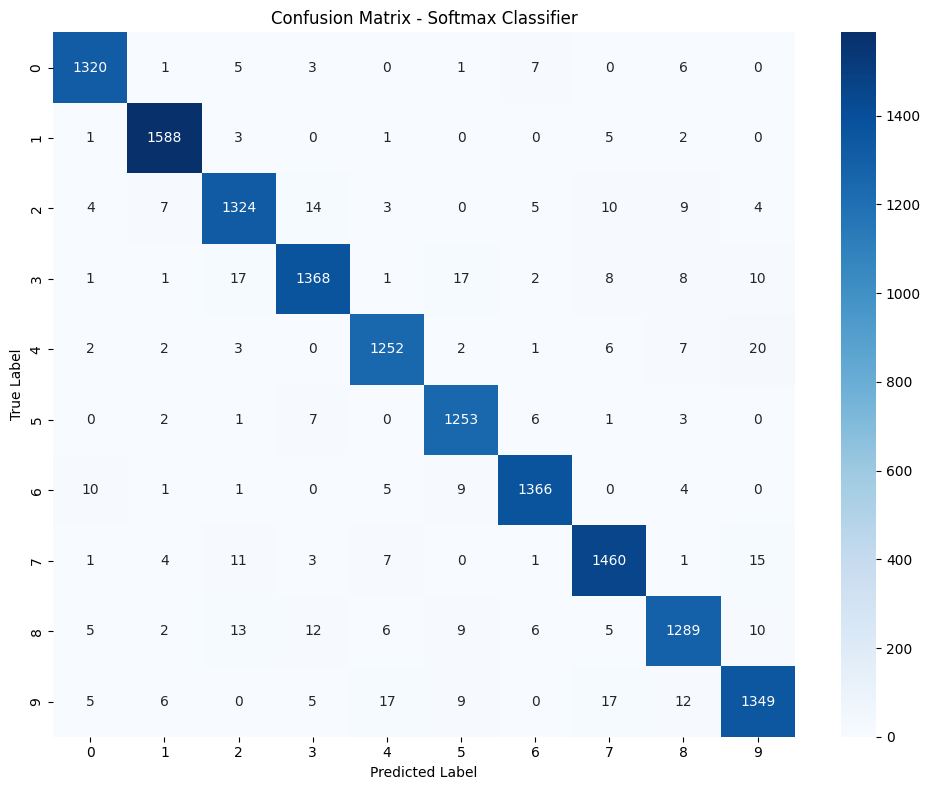

In [12]:
from src.utils.evaluation import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Generate confusion matrix
cm = confusion_matrix(y_test, preds)

print("Confusion Matrix:")
print(cm)

# Visualize the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, 
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Softmax Classifier')
plt.tight_layout()
plt.show()